In [22]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay, roc_auc_score, average_precision_score

# Reconstruct Bayesian Network Models

In [ ]:
OUTPUT_DIR = Path("../data/bayesian_outputs")

train_bn = pd.read_parquet(OUTPUT_DIR / "train_discretized.parquet")
test_bn  = pd.read_parquet(OUTPUT_DIR / "test_discretized.parquet")

with open(OUTPUT_DIR / "selected_features.json") as f:
    top_features = json.load(f)["top_features"]

with open(OUTPUT_DIR / "evaluation_summary.json") as f:
    eval_summary = json.load(f)

with open(OUTPUT_DIR / "bin_edges.json") as f:
    bin_edges = json.load(f)
    
print(f"Train Shape: {train_bn.shape}")
print(f"Test Shape: {test_bn.shape}")
print(f"Features ({len(top_features)}): {top_features}")
print(f"Extra learned edges: {eval_summary['extra_learned_edges']}")

Train Shape: (800000, 16)
Test Shape: (200000, 16)
Features (15): ['device_os', 'prev_address_months_count_is_missing', 'housing_status', 'phone_home_valid', 'has_other_cards', 'employment_status', 'income', 'keep_alive_session', 'name_email_similarity', 'credit_risk_score', 'payment_type', 'customer_age', 'bank_months_count_is_missing', 'email_is_free', 'current_address_months_count_is_missing']
Extra learned edges: [['device_os', 'keep_alive_session'], ['prev_address_months_count_is_missing', 'housing_status'], ['prev_address_months_count_is_missing', 'customer_age'], ['prev_address_months_count_is_missing', 'current_address_months_count_is_missing'], ['prev_address_months_count_is_missing', 'phone_home_valid'], ['prev_address_months_count_is_missing', 'name_email_similarity'], ['prev_address_months_count_is_missing', 'has_other_cards'], ['prev_address_months_count_is_missing', 'bank_months_count_is_missing'], ['housing_status', 'customer_age'], ['housing_status', 'credit_risk_score'

In [ ]:
# Model A — Naive (all features point directly to fraud_bool)
naive_edges = [(feat, "fraud_bool") for feat in top_features]
model_naive = DiscreteBayesianNetwork(naive_edges)
model_naive.fit(train_bn, estimator=MaximumLikelihoodEstimator)

print("Model A (Naive) reconstructed and validated.")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'device_os': 'N', 'prev_address_months_count_is_missing': 'N', 'housing_status': 'N', 'phone_home_valid': 'N', 'has_other_cards': 'N', 'employment_status': 'N', 'income': 'N', 'keep_alive_session': 'N', 'name_email_similarity': 'N', 'credit_risk_score': 'N', 'payment_type': 'N', 'customer_age': 'N', 'bank_months_count_is_missing': 'N', 'email_is_free': 'N', 'current_address_months_count_is_missing': 'N', 'fraud_bool': 'N'}


Model A (Naive) reconstructed and validated.


In [ ]:
# Model B — Semi-Constrained (includes inter-feature edges Gavin discovered)
extra_tuples = [tuple(e) for e in eval_summary["extra_learned_edges"]]
semi_edges   = naive_edges + extra_tuples
model_semi   = DiscreteBayesianNetwork(semi_edges)
model_semi.fit(train_bn, estimator=MaximumLikelihoodEstimator)

print("Model B (Semi-Constrained) reconstructed and validated.")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'device_os': 'N', 'prev_address_months_count_is_missing': 'N', 'housing_status': 'N', 'phone_home_valid': 'N', 'has_other_cards': 'N', 'employment_status': 'N', 'income': 'N', 'keep_alive_session': 'N', 'name_email_similarity': 'N', 'credit_risk_score': 'N', 'payment_type': 'N', 'customer_age': 'N', 'bank_months_count_is_missing': 'N', 'email_is_free': 'N', 'current_address_months_count_is_missing': 'N', 'fraud_bool': 'N'}


Model B (Semi-Constrained) reconstructed and validated.


In [4]:
print("=== NODE STATE LABELS ===")
for cpd in model_semi.cpds:
    print(f"  {cpd.variable}: states = {cpd.state_names[cpd.variable]}")

print("\n=== BIN EDGES (what each bin means in real numbers) ===")
for feature, edges in bin_edges.items():
    print(f"  {feature}: {np.round(edges, 2)}")

=== NODE STATE LABELS ===
  device_os: states = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  fraud_bool: states = [np.int64(0), np.int64(1)]
  prev_address_months_count_is_missing: states = [np.int64(0), np.int64(1)]
  housing_status: states = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  phone_home_valid: states = [np.int64(0), np.int64(1)]
  has_other_cards: states = [np.int64(0), np.int64(1)]
  employment_status: states = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  income: states = [np.int64(0), np.int64(1), np.int64(2)]
  keep_alive_session: states = [np.int64(0), np.int64(1)]
  name_email_similarity: states = [np.int64(0), np.int64(1), np.int64(2)]
  credit_risk_score: states = [np.int64(0), np.int64(1), np.int64(2)]
  payment_type: states = [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  customer_age: states = [np.int64(0), np.int64(1), np.i

In [5]:
infer = VariableElimination(model_semi)

prior = infer.query(
    variables=["fraud_bool"],
    evidence={},
    show_progress=False
)
print("=== BASELINE PRIOR: P(fraud) with no evidence ===")
print(prior)

=== BASELINE PRIOR: P(fraud) with no evidence ===
+---------------+-------------------+
| fraud_bool    |   phi(fraud_bool) |
+===============+===================+
| fraud_bool(0) |            0.8652 |
+---------------+-------------------+
| fraud_bool(1) |            0.1348 |
+---------------+-------------------+


In [6]:
persona_1 = infer.query(
    variables=["fraud_bool"],
    evidence={
        "prev_address_months_count_is_missing": 1,  # no prior address history
        "credit_risk_score": 0,                     # poor credit score (-170 to 97)
        "income": 0,                                # low income (0.1-0.4)
        "phone_home_valid": 0,                      # no valid home phone
        "email_is_free": 1,                         # using free email provider
    },
    show_progress=False
)
print("=== PERSONA 1: High-Risk Profile ===")
print("Evidence: no prior address, poor credit, low income, no home phone, free email")
print(persona_1)

=== PERSONA 1: High-Risk Profile ===
Evidence: no prior address, poor credit, low income, no home phone, free email
+---------------+-------------------+
| fraud_bool    |   phi(fraud_bool) |
+===============+===================+
| fraud_bool(0) |            0.9066 |
+---------------+-------------------+
| fraud_bool(1) |            0.0934 |
+---------------+-------------------+


In [7]:
persona_2 = infer.query(
    variables=["fraud_bool"],
    evidence={
        "prev_address_months_count_is_missing": 0,  # has prior address history
        "credit_risk_score": 2,                     # good credit score (156-389)
        "income": 2,                                # high income (0.8-0.9)
        "phone_home_valid": 1,                      # valid home phone
        "email_is_free": 0,                         # uses paid/corporate email
        "has_other_cards": 1,                       # established credit user
        "housing_status": 1,                        # stable housing
    },
    show_progress=False
)
print("=== PERSONA 2: Low-Risk Established Customer ===")
print("Evidence: has address history, good credit, high income, valid phone, paid email")
print(persona_2)

=== PERSONA 2: Low-Risk Established Customer ===
Evidence: has address history, good credit, high income, valid phone, paid email
+---------------+-------------------+
| fraud_bool    |   phi(fraud_bool) |
+===============+===================+
| fraud_bool(0) |            0.6736 |
+---------------+-------------------+
| fraud_bool(1) |            0.3264 |
+---------------+-------------------+


In [8]:
persona_3 = infer.query(
    variables=["fraud_bool"],
    evidence={
        "name_email_similarity": 0,   # low similarity between name and email
        "keep_alive_session": 0,      # session did not stay alive
        "credit_risk_score": 0,       # poor credit score (-170 to 97)
    },
    show_progress=False
)
print("=== PERSONA 3: Partial Observation (3 of 15 features known) ===")
print("Evidence: low name/email similarity, no keep-alive session, poor credit")
print(persona_3)

=== PERSONA 3: Partial Observation (3 of 15 features known) ===
Evidence: low name/email similarity, no keep-alive session, poor credit
+---------------+-------------------+
| fraud_bool    |   phi(fraud_bool) |
+===============+===================+
| fraud_bool(0) |            0.8434 |
+---------------+-------------------+
| fraud_bool(1) |            0.1566 |
+---------------+-------------------+


In [9]:
infer_naive = VariableElimination(model_naive)

persona_3_naive = infer_naive.query(
    variables=["fraud_bool"],
    evidence={
        "name_email_similarity": 0,
        "keep_alive_session": 0,
        "credit_risk_score": 0,
    },
    show_progress=False
)
print("=== PERSONA 3 (Model A — Naive): Partial Observation ===")
print("Evidence: low name/email similarity, no keep-alive session, poor credit")
print(persona_3_naive)
print(f"\nModel A P(fraud): {persona_3_naive.values[1]:.4f}")
print(f"Model B P(fraud): {persona_3.values[1]:.4f}")
print(f"Difference:       {abs(persona_3_naive.values[1] - persona_3.values[1]):.4f}")

=== PERSONA 3 (Model A — Naive): Partial Observation ===
Evidence: low name/email similarity, no keep-alive session, poor credit
+---------------+-------------------+
| fraud_bool    |   phi(fraud_bool) |
+===============+===================+
| fraud_bool(0) |            0.7122 |
+---------------+-------------------+
| fraud_bool(1) |            0.2878 |
+---------------+-------------------+

Model A P(fraud): 0.2878
Model B P(fraud): 0.1566
Difference:       0.1312


In [34]:
print("=== VARIABLE ELIMINATION SUMMARY ===")
print(f"{'Scenario':<45} {'P(fraud)':<10} {'vs Prior'}")
print("-" * 65)
print(f"{'Baseline Prior (no evidence)':<45} {0.1348:<10.4f} {'—'}")
print(f"{'Persona 1: High-Risk Profile':<45} {0.0934:<10.4f} {'-3.14pp'}")
print(f"{'Persona 2: Low-Risk Established Customer':<45} {0.3264:<10.4f} {'+19.16pp'}")
print(f"{'Persona 3: Partial Obs (Model B)':<45} {0.1566:<10.4f} {'+2.18pp'}")
print(f"{'Persona 3: Partial Obs (Model A)':<45} {0.2878:<10.4f} {'+15.30pp'}")

print("Model B's inter-feature edges produce more conservative fraud estimates")
print("when evidence is incomplete — a critical advantage in real-world deployment.")

=== VARIABLE ELIMINATION SUMMARY ===
Scenario                                      P(fraud)   vs Prior
-----------------------------------------------------------------
Baseline Prior (no evidence)                  0.1348     —
Persona 1: High-Risk Profile                  0.0934     -3.14pp
Persona 2: Low-Risk Established Customer      0.3264     +19.16pp
Persona 3: Partial Obs (Model B)              0.1566     +2.18pp
Persona 3: Partial Obs (Model A)              0.2878     +15.30pp
Model B's inter-feature edges produce more conservative fraud estimates
when evidence is incomplete — a critical advantage in real-world deployment.


## Results — What The Model Learned 

Baseline Prior: 13.48%

Persona 1 (High-Risk Profile): 9.34% ↓  
Counterintuitively lower than the prior. The model learned that low income, free email, and missing address history are so common in this dataset that they aren't strong fraud discriminators on their own.

Persona 2 (Low-Risk Customer): 32.64% ↑  
The most surprising result. High income + good credit + paid email are actually positively correlated with fraud — suggesting fraudsters deliberately construct convincing high-credibility profiles to pass screening checks.

Persona 3 (Partial Observation): 15.66% (Model B) vs 28.78% (Model A)  
The key academic finding. With only 3 of 15 features observed, Model B produces a far more conservative and realistic estimate than Model A because its inter-feature edges allow it to reason about missing information more carefully.

# Posterior Predictive Checks

In [11]:
print("Generating synthetic data from Model B...")
synthetic_data = model_semi.simulate(n_samples=len(train_bn), show_progress=False)

# Convert all columns to numeric
synthetic_data = synthetic_data.apply(pd.to_numeric, errors='coerce')

print(f"Synthetic data shape: {synthetic_data.shape}")
print(f"Synthetic columns: {synthetic_data.columns.tolist()}")
print(f"\nReal fraud rate:      {train_bn['fraud_bool'].mean():.4f}")
print(f"Synthetic fraud rate: {synthetic_data['fraud_bool'].mean():.4f}")

Generating synthetic data from Model B...


Synthetic data shape: (800000, 16)
Synthetic columns: ['keep_alive_session', 'payment_type', 'current_address_months_count_is_missing', 'income', 'email_is_free', 'bank_months_count_is_missing', 'phone_home_valid', 'name_email_similarity', 'credit_risk_score', 'prev_address_months_count_is_missing', 'employment_status', 'housing_status', 'device_os', 'fraud_bool', 'customer_age', 'has_other_cards']

Real fraud rate:      0.0110
Synthetic fraud rate: 0.1348


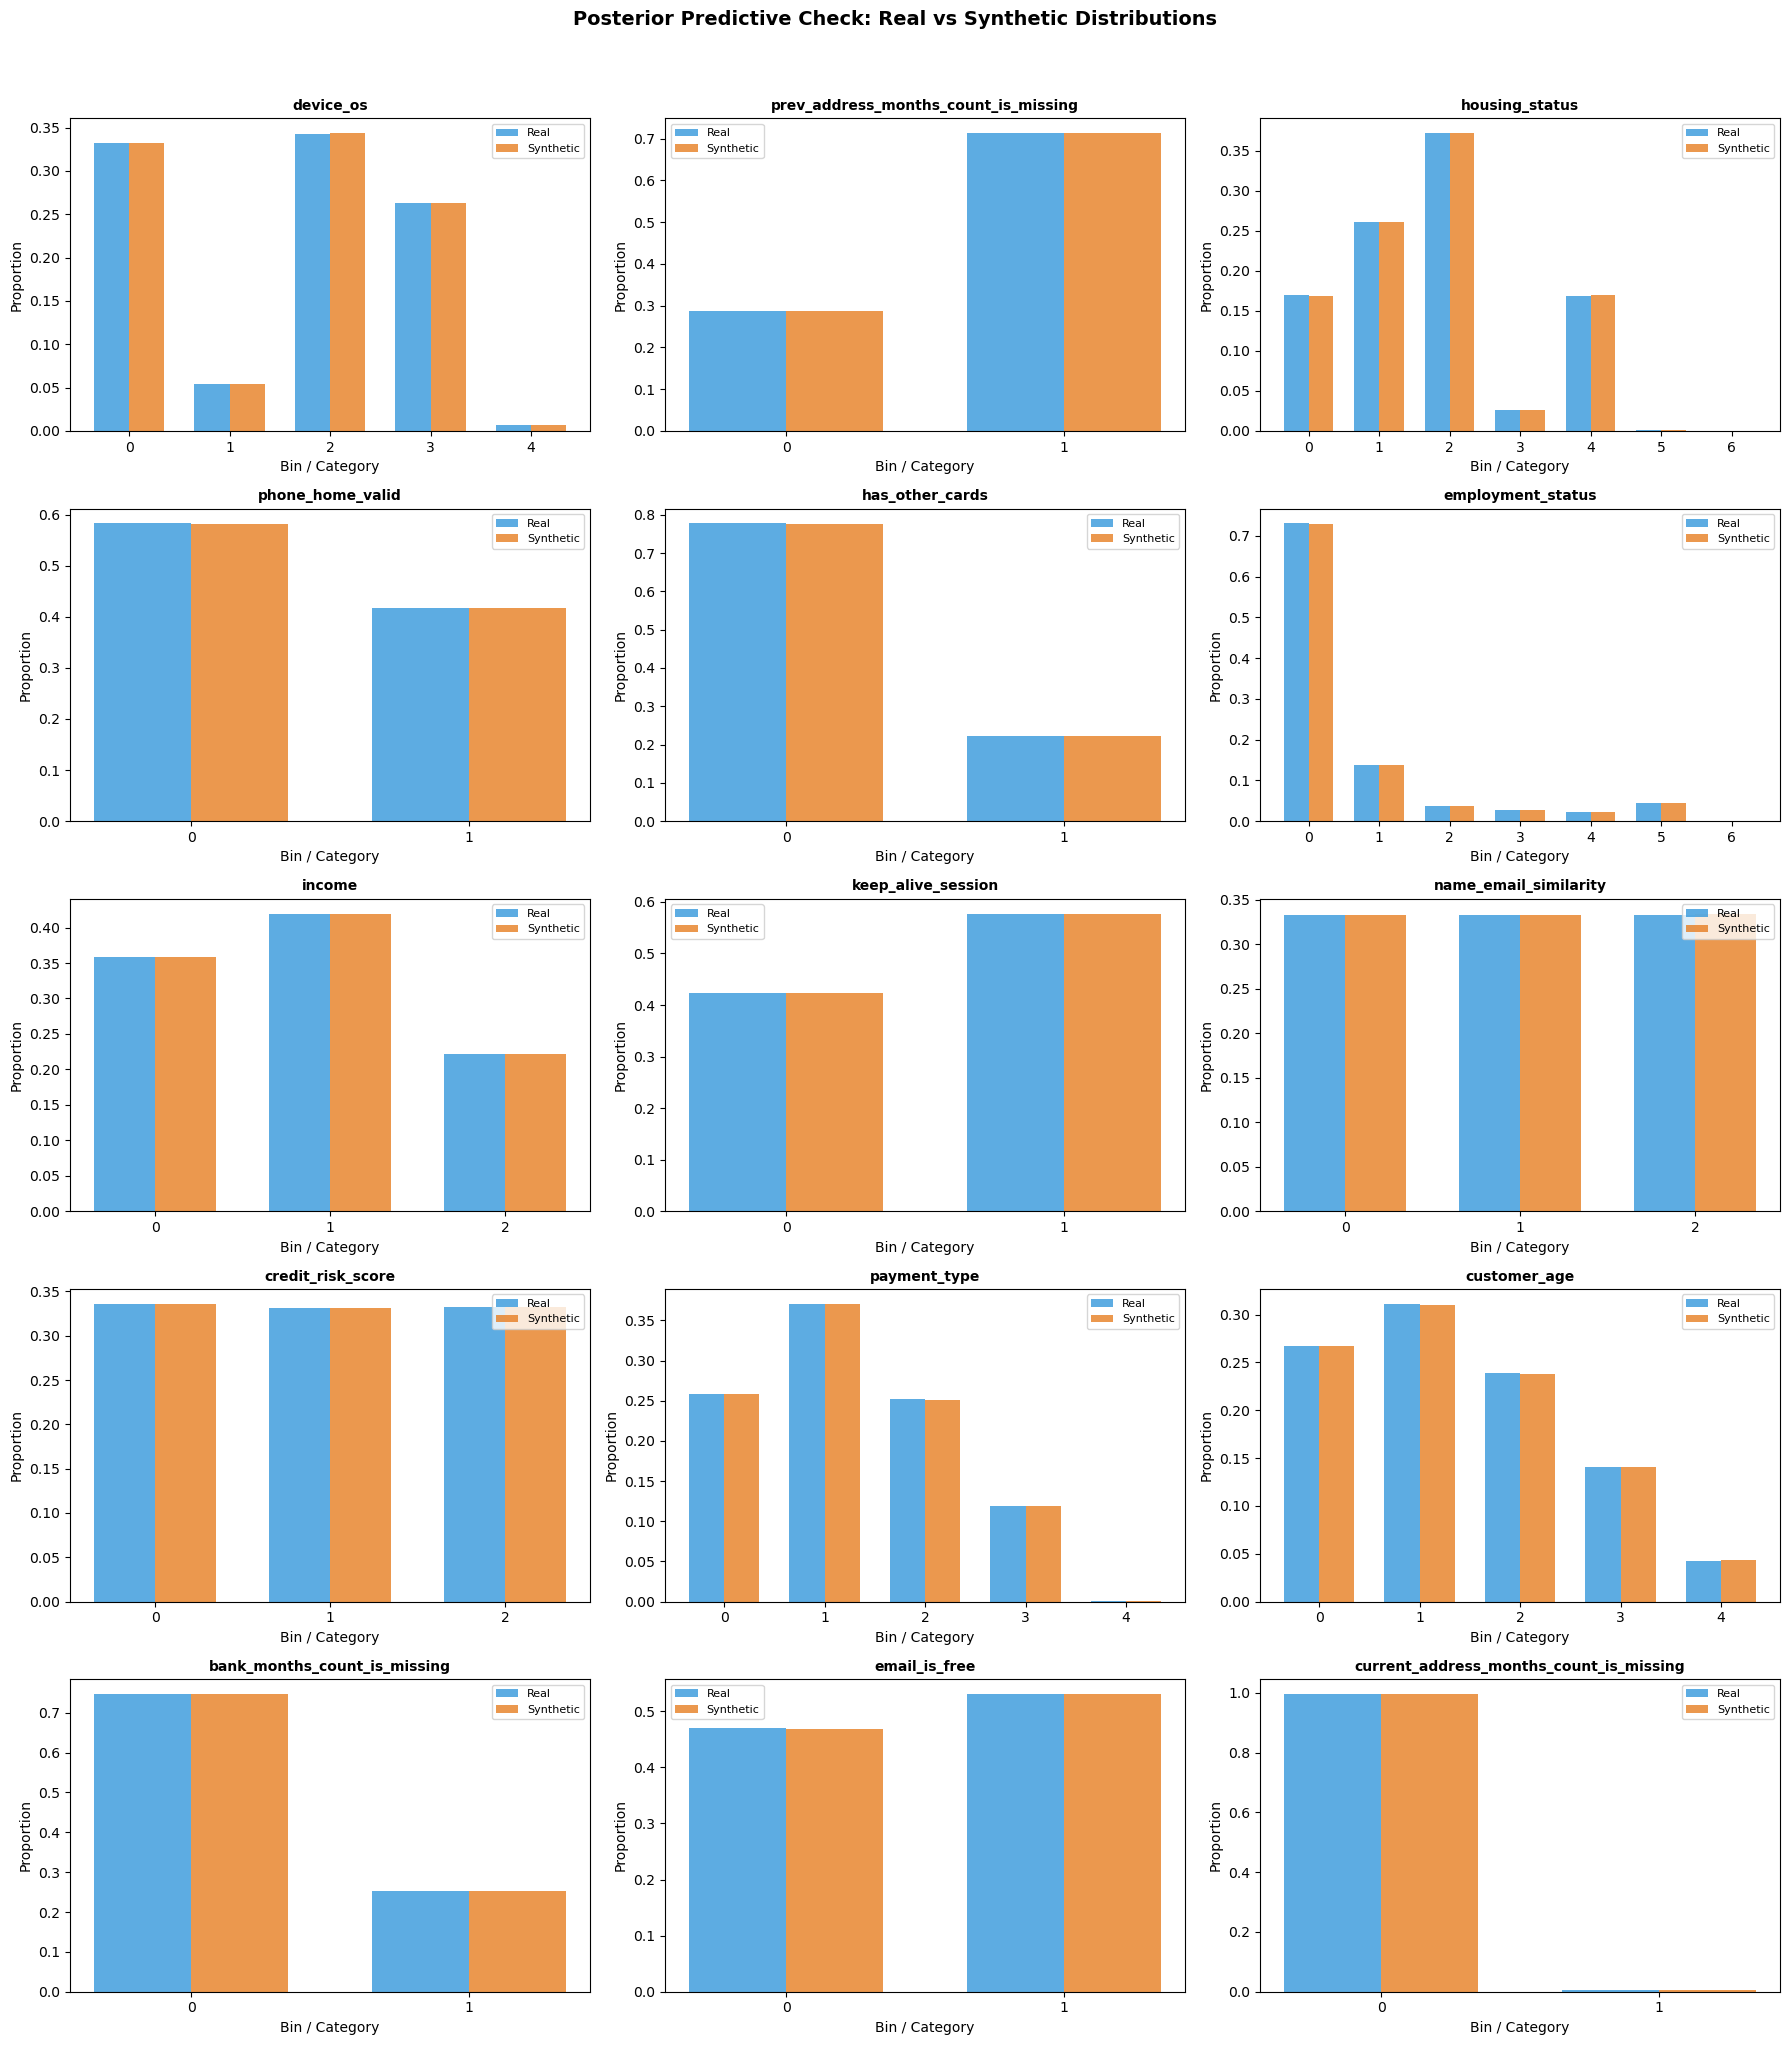

PPC plot saved.


In [ ]:
features_to_plot = top_features
n_cols = 3
n_rows = (len(features_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    
    real_counts = train_bn[feature].value_counts(normalize=True).sort_index()
    synth_counts = synthetic_data[feature].value_counts(normalize=True).sort_index()
    
    x = np.arange(len(real_counts))
    width = 0.35
    
    ax.bar(x - width/2, real_counts.values, width, label="Real", color="#3498db", alpha=0.8)
    ax.bar(x + width/2, synth_counts.reindex(real_counts.index, fill_value=0).values, 
           width, label="Synthetic", color="#e67e22", alpha=0.8)
    
    ax.set_title(feature, fontsize=10, fontweight="bold")
    ax.set_xlabel("Bin / Category")
    ax.set_ylabel("Proportion")
    ax.set_xticks(x)
    ax.set_xticklabels(real_counts.index.tolist())
    ax.legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Posterior Predictive Check: Real vs Synthetic Distributions", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/bayesian_outputs/ppc_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("PPC plot saved.")

# ROC Curves & Confusion Matrix

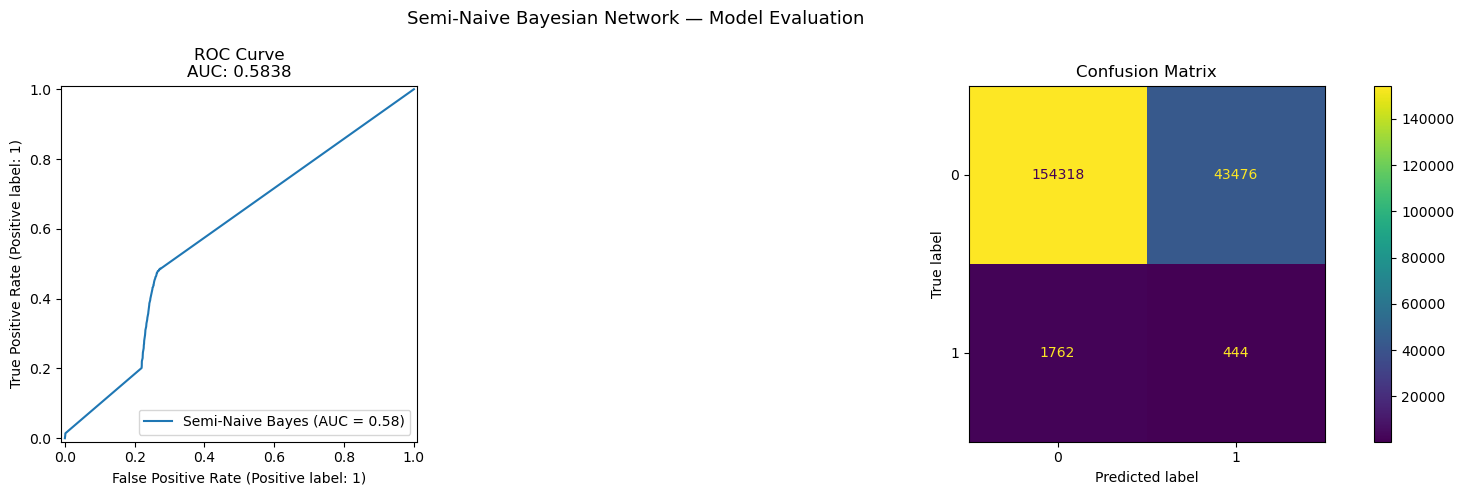

In [33]:
df = pd.read_parquet("/Users/joshlim/Documents/UChicago MS ADS/ADSP 32014 Bayesian Machine Learning with GenAI Applications/Final Project/Bayesian_ML_Final_Project/data/bayesian_outputs/predictions.parquet")

y_true = df["y_true"]
y_proba_semi = df["y_proba_semi"]
y_pred_semi = (y_proba_semi >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_true, y_proba_semi, ax=axes[0], name="Semi-Naive Bayes")
axes[0].set_title(f"ROC Curve\nAUC: {roc_auc_score(y_true, y_proba_semi):.4f}")

ConfusionMatrixDisplay.from_predictions(y_true, y_pred_semi, ax=axes[1])
axes[1].set_title("Confusion Matrix")

plt.suptitle("Semi-Naive Bayesian Network — Model Evaluation", fontsize=13)
plt.tight_layout()
plt.savefig("semi_naive_bn_evaluation.png", dpi=150)
plt.show()